Aim is to get at least .75 on f1-score

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTENC

In [2]:
train = pd.read_pickle("train_processed.pkl")
test = pd.read_pickle("test_processed.pkl")

me_train = pd.read_csv('mean_enc_train.csv')
me_test = pd.read_csv('mean_enc_test.csv')

In [12]:
test

,Art and design,Auto and vehicles,Beauty,Books and reference,Business,Comics,Communication,Dating,Education,Entertainment,...,Unrated,Id,is_Paid,Varies with device count,Last updated days,Installs,Current Ver,Size_in_Kilo,Android Ver,Price
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0,10.0,545,10000000,2.20,15360.0,4.1,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1,0,3.0,136,5000,2017.07,2560.0,4.1,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2,0,3.0,303,100000,3.10,2867.2,4.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3,0,0.0,501,50000000,1.90,37888.0,2.3,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4,0,0.0,143,50000,2.00,21504.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1523,0,19.0,2590,5000000,1.40,4198.4,2.0,0.0
1524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1524,0,3.0,508,50000,1.20,40960.0,4.0,0.0
1525,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1525,0,0.0,146,5000,8.20,5017.6,4.0,0.0
1526,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1526,0,2.0,302,5000000,3.10,29696.0,4.1,0.0


In [13]:
me_test

,Rating,Reviews,Installs,Price,Current Ver,Android Ver,Size_in_Kilo,is_Paid,Last updated days,Varies with device count,Category_me,CR_me,Id
0,4.0,328619,10000000,0.0,2.20,4.1,15360.0,0,545,10.0,0.760731,0.773751,0
1,4.4,58,5000,0.0,2017.07,4.1,2560.0,0,136,3.0,0.722986,0.773751,1
2,4.1,278,100000,0.0,3.10,4.0,2867.2,0,303,3.0,0.722986,0.773751,2
3,4.5,2371338,50000000,0.0,1.90,2.3,37888.0,0,501,0.0,0.920398,1.113235,3
4,4.9,2739,50000,0.0,2.00,3.0,21504.0,0,143,0.0,0.545455,0.773751,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523,3.7,38767,5000000,0.0,1.40,2.0,4198.4,0,2590,19.0,1.433687,1.330709,1523
1524,4.6,623,50000,0.0,1.20,4.0,40960.0,0,508,3.0,0.895954,1.330709,1524
1525,4.9,776,5000,0.0,8.20,4.0,5017.6,0,146,0.0,0.690647,0.909722,1525
1526,4.1,78298,5000000,0.0,3.10,4.1,29696.0,0,302,2.0,0.544601,0.773751,1526


In [3]:
def rank_installs(value):
    
    if value in range(0, 50001):    
        return 0
    
    elif value in range(50001, 1000001):
        return 1
    
    elif value in range(1000001, 50000001):
        return 2
    
    else:
        return 3
    
    
train['Installs'] = train['Installs'].apply(lambda x: rank_installs(x))
test['Installs'] = test['Installs'].apply(lambda x: rank_installs(x))

In [4]:
train[train['Installs'] == 3]

,Art and design,Auto and vehicles,Beauty,Books and reference,Business,Comics,Communication,Dating,Education,Entertainment,...,Teen,is_Paid,Current Ver,Varies with device count,Price,Size_in_Kilo,Last updated days,Android Ver,more_than_100k,Installs
38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,1.520,19.0,0.0,10137.6,307,4.0,1,3
82,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,1.129,19.0,0.0,75776.0,214,4.1,1,3
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,2.300,19.0,0.0,99328.0,163,4.1,1,3
145,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,4.000,19.0,0.0,53248.0,129,4.0,1,3
203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,5.420,3.0,0.0,7270.4,302,2.3,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5967,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,1.490,19.0,0.0,63488.0,214,4.0,1,3
5972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,1.490,19.0,0.0,63488.0,214,4.0,1,3
6039,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0,5.200,1.0,0.0,13312.0,333,4.4,1,3
6055,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,2.347,10.0,0.0,68608.0,129,4.1,1,3


In [5]:
train.columns

Index(['Art and design', 'Auto and vehicles', 'Beauty', 'Books and reference',
       'Business', 'Comics', 'Communication', 'Dating', 'Education',
       'Entertainment', 'Events', 'Family', 'Finance', 'Food and drink',
       'Game', 'Health and fitness', 'House and home', 'Libraries and demo',
       'Lifestyle', 'Maps and navigation', 'Medical', 'News and magazines',
       'Parenting', 'Personalization', 'Photography', 'Productivity',
       'Shopping', 'Social', 'Sports', 'Tools', 'Travel and local',
       'Video players', 'Weather', 'Adults only 18+', 'Everyone',
       'Everyone 10+', 'Mature 17+', 'Teen', 'is_Paid', 'Current Ver',
       'Varies with device count', 'Price', 'Size_in_Kilo',
       'Last updated days', 'Android Ver', 'more_than_100k', 'Installs'],
      dtype='object')

In [6]:
train

,Art and design,Auto and vehicles,Beauty,Books and reference,Business,Comics,Communication,Dating,Education,Entertainment,...,Teen,is_Paid,Current Ver,Varies with device count,Price,Size_in_Kilo,Last updated days,Android Ver,more_than_100k,Installs
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,1.0,10.0,0.0,52224.0,687,2.3,1,1
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,6.1,0.0,0.0,4710.4,155,5.0,1,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,2.9,0.0,0.0,10240.0,169,4.1,0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1,1.0,2.0,400.0,7475.2,277,4.1,0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,1.0,10.0,0.0,6963.2,165,2.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,6.1,3.0,0.0,27648.0,130,4.2,0,1
6105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,1.0,10.0,0.0,12288.0,258,4.0,1,2
6106,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,4.0,1.0,0.0,35840.0,129,4.0,1,1
6107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,6.0,3.0,0.0,7884.8,589,3.0,1,1


In [4]:
categoricals = [i for i in range(39)]

categoricals = categoricals + [45]

In [11]:
sm = SMOTENC(random_state=42, categorical_features = categoricals,sampling_strategy={0: 2520, 1: 2333, 2: 1283, 3: 1100})


In [12]:
X_train = train.drop('Installs', axis=1)
y_train = train[['Installs']].copy()

In [13]:
train.shape

(6109, 48)

In [14]:
X_train.shape

(6109, 47)

In [15]:
X_train['me_cat'] = me_train['Category_me'].copy()
X_train['me_rat'] = me_train['CR_me'].copy()

In [16]:
X_smoted, y_smoted = sm.fit_resample(X_train, y_train)

X_smoted = pd.DataFrame(X_smoted, columns=X_train.columns)

C:\python\lib\site-packages\imblearn\utils\_validation.py:299: UserWarning: After over-sampling, the number of samples (2520) in class 0 will be larger than the number of samples in the majority class (class #0 -> 2519)
  warnings.warn(


In [17]:
me_train

,Installs,Reviews,is_Paid,Varies with device count,Last updated days,Installs.1,Current Ver,Size_in_Kilo,Rating,Android Ver,Price,Category_me,CR_me
0,0,59,0,19.0,490,1000,0.100,1433.6,4.3,2.3,0.00,1.433687,0.773751
1,0,131,0,3.0,1068,5000,1.060,3481.6,4.1,1.6,0.00,0.895954,0.773751
2,0,395,1,3.0,144,1000,6.500,19456.0,4.6,5.0,9.99,0.250923,0.773751
3,1,818,0,0.0,853,100000,4.423,5427.2,3.7,4.0,0.00,0.920398,0.773751
4,0,75,0,3.0,632,10000,2.500,1945.6,4.0,2.2,0.00,0.722986,0.773751
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6104,0,51,1,3.0,1507,1000,2.000,2457.6,3.4,4.0,29.99,0.250923,0.773751
6105,1,6238,0,3.0,130,500000,1.100,3993.6,4.5,4.1,0.00,0.895954,0.773751
6106,0,294,0,2.0,2101,10000,1.000,153.0,4.0,2.1,0.00,0.544601,0.773751
6107,0,3,0,10.0,256,50,1.000,154.0,5.0,3.0,0.00,0.760731,0.773751


In [18]:
me_cols = ['Current Ver', 'Size_in_Kilo', 'Android Ver', 'is_Paid', 'Varies with device count', 'Price', 'Last updated days', 'me_cat', 'me_rat']

In [19]:
me_train = X_smoted[me_cols].copy()

In [20]:
me_train_labels = y_smoted.copy()

In [21]:
X_smoted.drop(['me_cat', 'me_rat'], axis=1, inplace=True)

In [22]:
X_test = test.drop('Installs', axis=1)
y_test = test[['Installs']].copy()

In [23]:
X_smoted.drop('more_than_100k', axis=1, inplace=True)

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, roc_auc_score, make_scorer
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
models = []

xgb_clf = xgb.XGBClassifier(learning_rate=0.01, objective='multi:softmax', num_class=4, n_jobs=-1, max_depth=16, min_child_weight=2, n_estimators=1000, colsample_bytree=0.8)

def KFold_validation(X, y, model, kfold):
    
    i = 0 
    for train_indices, test_indices in kfold.split(X, y):
    
        train_X, test_X = X.iloc[train_indices], X.iloc[test_indices]
        train_y, test_y = y.iloc[train_indices], y.iloc[test_indices]
    
        model.fit(train_X, train_y)
    
        score = f1_score(test_y, model.predict(test_X), average='weighted')
    
        print(f'Scoring in {i} iteration is : {score}')
        i+=1
    
        scores.append(score)
        models.append(model)
    
    print(f'Average f1 score for set is {np.mean(scores)}')
    
    return (scores, models)
        
        

In [22]:
kfold_scores, kfold_models = KFold_validation(X_smoted, y_smoted, xgb_clf, kfold)

C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


[15:19:30] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Scoring in 0 iteration is : 0.6523267507787108
[15:20:44] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 1 iteration is : 0.669896687766233
[15:22:01] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 2 iteration is : 0.682166870000362
[15:23:13] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 3 iteration is : 0.6438863612518471
[15:24:22] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 4 iteration is : 0.6657276547118335
Average f1 score for set is 0.6628008649017973


In [23]:
np.mean(kfold_scores)

0.6628008649017973

In [24]:
kfold_scores

[0.6523267507787108,
 0.669896687766233,
 0.682166870000362,
 0.6438863612518471,
 0.6657276547118335]

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [26]:
confusion_matrix(y_smoted, kfold_models[3].predict(X_smoted))

array([[2369,  127,   20,    1],
       [ 150, 2120,   54,    9],
       [  30,   95, 1145,   13],
       [   0,    8,    7, 1085]], dtype=int64)

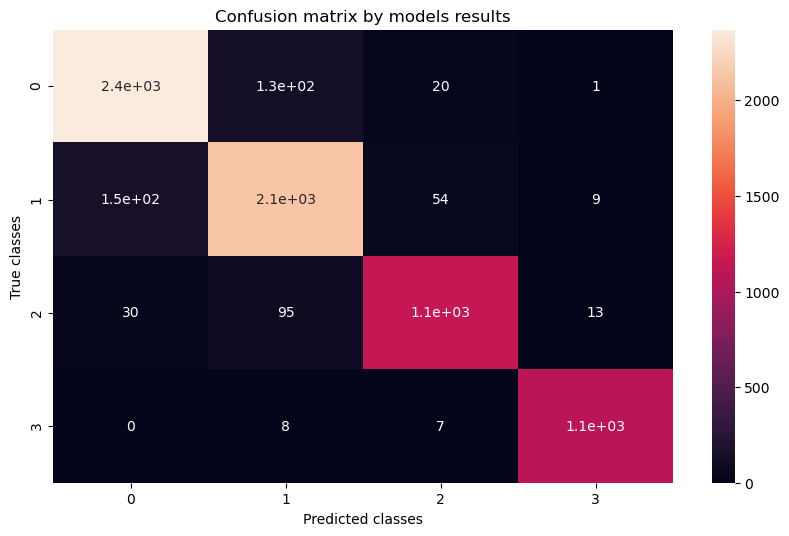

In [27]:
plt.figure(figsize=(10, 6), dpi=100)

plt.title('Confusion matrix by models results')

sns.heatmap(confusion_matrix(y_smoted, kfold_models[1].predict(X_smoted)), annot=True)

plt.ylabel('True classes')
plt.xlabel('Predicted classes')

plt.show()

We can see here that apps in 1st and 2nd class are often misinterpreted as other classes.

Task is somehow make difference between them more recognizable

Round 1 of improving the score

In [28]:
X_smoted

,Art and design,Auto and vehicles,Beauty,Books and reference,Business,Comics,Communication,Dating,Education,Entertainment,...,Everyone 10+,Mature 17+,Teen,is_Paid,Current Ver,Varies with device count,Price,Size_in_Kilo,Last updated days,Android Ver
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,1.000000,10.000000,0.0,52224.000000,687,2.300000
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,6.100000,0.000000,0.0,4710.400000,155,5.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,2.900000,0.000000,0.0,10240.000000,169,4.100000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,1.000000,2.000000,400.0,7475.200000,277,4.100000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,1.000000,10.000000,0.0,6963.200000,165,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,1.983987,19.000000,0.0,32952.330688,129,4.018001
7229,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,5.163801,4.416889,0.0,71680.000000,129,4.760900
7230,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0,3.371120,17.140439,0.0,43008.000000,284,4.041324
7231,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,9.800000,2.000000,0.0,11264.000000,135,4.000000


In [26]:
smoted = X_smoted.copy()
smoted['class'] = y_smoted.copy()

In [27]:
smoted['mean_cls'] = smoted['is_Paid'].map(smoted.groupby('is_Paid')['class'].mean())

In [28]:
test['mean_cls'] = test['is_Paid'].map(smoted.groupby('is_Paid')['class'].mean())

In [29]:
X_train = smoted.drop('class', axis=1)
y_train = smoted[['class']].copy()

In [33]:
kfold_scores, kfold_models = KFold_validation(X_train, y_train, xgb_clf, kfold)

C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


[15:25:44] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Scoring in 0 iteration is : 0.6503407512085508
[15:26:58] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 1 iteration is : 0.6744236788946455
[15:28:13] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 2 iteration is : 0.6871018656939695
[15:29:26] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 3 iteration is : 0.6388809261097295
[15:30:40] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 4 iteration is : 0.6726620766790035
Average f1 score for set is 0.6637413623094885


In [30]:
sm = SMOTENC(random_state=42, categorical_features = categoricals,sampling_strategy={0: 3000, 1: 3000, 2: 2000, 3: 1200})

X_train, y_train = sm.fit_resample(X_train, y_train)

X_train = pd.DataFrame(X_train, columns=X_train.columns)

C:\python\lib\site-packages\imblearn\utils\_validation.py:299: UserWarning: After over-sampling, the number of samples (3000) in class 0 will be larger than the number of samples in the majority class (class #0 -> 2520)
  warnings.warn(
C:\python\lib\site-packages\imblearn\utils\_validation.py:299: UserWarning: After over-sampling, the number of samples (3000) in class 1 will be larger than the number of samples in the majority class (class #0 -> 2520)
  warnings.warn(


In [35]:
X_train.shape

(9200, 46)

In [36]:
scores = []
models = []
kfold_scores, kfold_models = KFold_validation(X_train, y_train, xgb_clf, kfold)

C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


[15:32:04] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Scoring in 0 iteration is : 0.6931579006195312
[15:33:42] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 1 iteration is : 0.6977359331392468
[15:35:17] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 2 iteration is : 0.7159808323718092
[15:36:53] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 3 iteration is : 0.6853832896309676
[15:38:31] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


Scoring in 4 iteration is : 0.7084487247399149
Average f1 score for set is 0.7001413361002939


In [37]:
kfold_scores

[0.6931579006195312,
 0.6977359331392468,
 0.7159808323718092,
 0.6853832896309676,
 0.7084487247399149]

In [44]:
X_train.shape

(9200, 46)

In [38]:
confusion_matrix(y_train, kfold_models[0].predict(X_train))

array([[2833,  143,   22,    2],
       [ 165, 2750,   81,    4],
       [  25,  112, 1854,    9],
       [   1,    5,   10, 1184]], dtype=int64)

### Hyper parameters tuning 

In [39]:
y_train['class'] == 1

0        True
1        True
2        True
3       False
4        True
        ...  
9195    False
9196    False
9197    False
9198    False
9199    False
Name: class, Length: 9200, dtype: bool

In [31]:
xgb_clf = xgb.XGBClassifier(min_child_weight=2, base_score=0.2, reg_lambda=0.5, reg_alpha=1, gamma=0, learning_rate=0.9, n_estimators=500)

In [41]:
X_train

,Art and design,Auto and vehicles,Beauty,Books and reference,Business,Comics,Communication,Dating,Education,Entertainment,...,Mature 17+,Teen,is_Paid,Current Ver,Varies with device count,Price,Size_in_Kilo,Last updated days,Android Ver,mean_cls
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,1.000000,10.000000,0.0,52224.000000,687,2.30000,1.198023
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,6.100000,0.000000,0.0,4710.400000,155,5.00000,1.198023
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,2.900000,0.000000,0.0,10240.000000,169,4.10000,1.198023
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1,1.000000,2.000000,400.0,7475.200000,277,4.10000,0.175439
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,1.000000,10.000000,0.0,6963.200000,165,2.00000,1.198023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,7.900000,19.000000,0.0,99328.000000,197,4.10000,1.198023
9196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,2.117326,14.803018,0.0,12526.761629,416,4.16995,1.198023
9197,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,2.600000,19.000000,0.0,47104.000000,275,4.10000,1.198023
9198,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,2.347000,14.704267,0.0,68608.000000,129,4.10000,1.198023


In [32]:
tr = X_train.drop(['mean_cls', 'Varies with device count'], axis=1).copy()

In [33]:
xgboost_cls = xgb_clf.fit(tr, y_train)

C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


[21:53:12] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


In [34]:
scores = []
models = []
kfold_scores, kfold_models = KFold_validation(tr, y_train, xgb_clf, kfold)

C:\python\lib\site-packages\xgboost\sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\python\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


[21:53:20] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


KeyboardInterrupt: 

In [ ]:
X_train

In [ ]:
classes = [0, 1, 2, 3]
tuned_models = []
for cls in classes:
    y_this_class = (y_train['class'] == cls)
    model_tuned = GridSearchCV(xgb_clf, param_grid=params, scoring='f1', n_jobs=4)
    model_tuned.fit(X_train, y_this_class)
    
    tuned_models.append(model_tuned)
    print(f'{cls} is done')

### Creating second model.

In [45]:
me_train.shape

(7233, 9)

In [46]:
me_train_labels

,Installs
0,1
1,1
2,1
3,0
4,1
...,...
7228,3
7229,3
7230,3
7231,3


In [35]:
from sklearn.ensemble import RandomForestClassifier


clf = RandomForestClassifier(class_weight='balanced', min_samples_leaf=40, max_depth=13, max_features=6, n_estimators=700)

classes = [0, 1, 2, 3]

tuned_models_RF = []

'''
for cls in classes:
    y_this_class = (me_train_labels['Installs'] == cls)
    model_tuned = GridSearchCV(clf, param_grid=params, scoring='f1', n_jobs=4)
    model_tuned.fit(me_train, y_this_class)
    
    tuned_models_RF.append(model_tuned)
    print(f'{cls} is done')
'''

"\nfor cls in classes:\n    y_this_class = (me_train_labels['Installs'] == cls)\n    model_tuned = GridSearchCV(clf, param_grid=params, scoring='f1', n_jobs=4)\n    model_tuned.fit(me_train, y_this_class)\n    \n    tuned_models_RF.append(model_tuned)\n    print(f'{cls} is done')\n"

In [43]:
clf.fit(me_train, me_train_labels)

<ipython-input-43-8b5a681b9ddb>:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  clf.fit(me_train, me_train_labels)


RandomForestClassifier(class_weight='balanced', max_depth=13, max_features=6,
                       min_samples_leaf=40, n_estimators=700)

In [38]:
me_test.drop(['Rating', 'Reviews'], axis=1, inplace=True)

In [41]:
me_test['Installs'] = me_test['Installs'].apply(lambda x: rank_installs(x))

In [50]:
ids = pd.DataFrame({'id': me_test['Id'], 'actual_classes': me_test['Installs']})

In [47]:
test.drop(['Id', 'mean_cls', 'Varies with device count', 'Installs'], axis=1, inplace=True)

In [53]:
me_test.drop(['Id'], axis=1, inplace=True)

In [51]:
ids['Xgboost_preds'] = xgb_clf.predict(test)

In [55]:
me_train

,Current Ver,Size_in_Kilo,Android Ver,is_Paid,Varies with device count,Price,Last updated days,me_cat,me_rat
0,0.100000,1433.600000,2.300000,0,19.000000,0.00,490,1.433687,0.773751
1,1.060000,3481.600000,1.600000,0,3.000000,0.00,1068,0.895954,0.773751
2,6.500000,19456.000000,5.000000,1,3.000000,9.99,144,0.250923,0.773751
3,4.423000,5427.200000,4.000000,0,0.000000,0.00,853,0.920398,0.773751
4,2.500000,1945.600000,2.200000,0,3.000000,0.00,632,0.722986,0.773751
...,...,...,...,...,...,...,...,...,...
7231,1.740886,63168.861079,4.155830,0,19.000000,0.00,232,1.433687,0.773751
7232,5.100000,71680.000000,2.300000,0,19.000000,0.00,134,1.433687,0.773751
7233,10.906932,41809.194262,4.224394,0,2.170709,0.00,195,1.083602,1.113235
7234,1.900000,90112.000000,3.000000,0,19.000000,0.00,303,1.433687,1.330709


In [57]:
me_test.drop(['Installs'], axis=1, inplace=True)

In [59]:
ids['Rf_preds'] = clf.predict(me_test)

In [62]:
ids['Rf_preds'].value_counts()

0    1515
2       9
1       2
3       2
Name: Rf_preds, dtype: int64

In [64]:
ids['actual_classes'].value_counts()

0    616
1    569
2    298
3     45
Name: actual_classes, dtype: int64

In [65]:
ids['Xgboost_preds'].value_counts()

0    632
1    560
2    291
3     45
Name: Xgboost_preds, dtype: int64

In [69]:
f1_score(ids['actual_classes'], ids['Xgboost_preds'], average='macro')

0.6032451737310738

In [71]:
ids[ids['actual_classes'] == ids['Xgboost_preds']]

,id,actual_classes,Xgboost_preds,Rf_preds
6,6,1,1,0
8,8,0,0,0
9,9,0,0,0
12,12,1,1,0
13,13,0,0,0
...,...,...,...,...
1521,1521,0,0,0
1522,1522,1,1,0
1523,1523,2,2,0
1525,1525,0,0,0


In [89]:
ids['Comb_pred'] = round(ids['Xgboost_preds'] * 0.95 + ids['Rf_preds'] * 0.05)

In [85]:
ids

,id,actual_classes,Xgboost_preds,Rf_preds,Comb_pred
0,0,2,1,0,0.0
1,1,0,1,0,0.0
2,2,1,0,0,0.0
3,3,2,1,0,0.0
4,4,0,1,0,0.0
...,...,...,...,...,...
1523,1523,2,2,0,1.0
1524,1524,0,2,0,1.0
1525,1525,0,0,0,0.0
1526,1526,2,2,0,1.0


In [90]:
f1_score(ids['actual_classes'], ids['Comb_pred'], average='macro')

0.6032451737310738